# `SpatialEcoTyper` (R) to `pyspatialecotyper` (Python): a function-level dictionary

**Who this notebook is for.** You have R code that calls `SpatialEcoTyper`
1.0.4 and you want to port it to Python. For **every public R function** this
notebook gives you: a one-paragraph description citing the upstream help page
in `SpatialEcoTyper-ref/man/`, a **complete parameter table** (every R
argument gets a row, with renames and Python-only additions flagged), the R
one-liner you would have written, the Python call that replaces it, and a
**numerical comparison** of the two outputs on the *same* input.

This is not the same as the other two notebooks:

* `compare_R_vs_Python.ipynb` is **pipeline-level** parity - the whole thing
  run end to end.
* `tutorial_melanoma.ipynb` is a **Python-only** tour of the API.
* This notebook is **function-level**: each function called in isolation, in
  both languages, on one shared fixture.

The R side is executed once, at the top, by `examples/r_per_function_dump.R`.
Every R one-liner below is rendered as a *markdown* code block - it is not
executed by this notebook's kernel, because the kernel is Python.

Every threshold is read from `data/manifest.yaml`, the parity gate that was
committed **before** any algorithmic Python was written. Nothing here
hard-codes a pass mark.

In [1]:
import json
import os
import subprocess
import sys
import time

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import yaml
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import adjusted_rand_score

REPO = os.path.abspath(os.path.join(os.getcwd(), ".."))
for p in (REPO, os.path.join(REPO, "tests")):
    if p not in sys.path:
        sys.path.insert(0, p)

import rio                                   # the R-dump readers, from tests/
import pyspatialecotyper as se
from pyspatialecotyper import rrandom
from pyspatialecotyper import stats as se_stats
from pyspatialecotyper import nmf as se_nmf

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

with open(os.path.join(REPO, "data", "manifest.yaml")) as fh:
    MANIFEST = yaml.safe_load(fh)
GATES = {o["name"]: o for o in MANIFEST["outputs"]}
print("upstream :", MANIFEST["upstream"]["name"], MANIFEST["upstream"]["version"])
print("gates    :", len(GATES), "pre-registered outputs")
print("port     : pyspatialecotyper", se.__version__)

upstream : SpatialEcoTyper 1.0.4
gates    : 26 pre-registered outputs
port     : pyspatialecotyper 0.1.0


## Setup - run the R driver

`examples/r_per_function_dump.R` builds a deterministic fixture (a contiguous
spatial crop of the melanoma sample; no RNG anywhere in its construction),
calls each R function in isolation and dumps the result using the conventions
of `tests/r_reference_driver.R`.

It is invoked **three** times. The `nmfclust` part has to be its own R
process: `NMF:::nmf.stop.connectivity` keeps `.consold` inside a `local({})`
closure, i.e. as process-global state, so factorising matrices of different
shapes in one session aborts with `cons != .consold : non-conformable
arrays`.

In [2]:
RSCRIPT = os.environ.get("R_TEST_RSCRIPT",
                         "/scratch/users/steorra/env/CMAP/bin/Rscript")
R_LIBS = os.environ.get(
    "R_LIBS", "/scratch/users/steorra/Rlibs_set:"
              "/scratch/users/steorra/env/CMAP/lib/R/library")
TMPDIR = os.environ.get("TMPDIR", "/scratch/users/steorra/tmp")
OUT = os.environ.get("R_PERFUNC_OUT",
                     os.path.join(TMPDIR, "py_spatialecotyper_perfunc"))
os.makedirs(OUT, exist_ok=True)

DRIVER = os.path.join(os.getcwd(), "r_per_function_dump.R")
NCELLS = "3000"
renv = dict(os.environ, R_LIBS=R_LIBS, TMPDIR=TMPDIR)

r_wall = {}
for part in ("main", "nmf", "nmfclust"):
    t0 = time.time()
    cp = subprocess.run([RSCRIPT, DRIVER, OUT, "", "", part, NCELLS],
                        capture_output=True, text=True, env=renv,
                        cwd=os.path.dirname(DRIVER))
    r_wall[part] = time.time() - t0
    ok = cp.returncode == 0
    print(f"[{part:8s}] returncode {cp.returncode}  {r_wall[part]:6.1f} s")
    if not ok:
        print(cp.stdout[-3000:]); print(cp.stderr[-3000:])
        raise RuntimeError(f"r_per_function_dump.R part={part} failed")

print("\nR version used:")
print(subprocess.run([RSCRIPT, "-e",
                      'cat(R.version.string, "|",'
                      ' as.character(packageVersion("SpatialEcoTyper")), "|",'
                      ' as.character(packageVersion("Seurat")), "|",'
                      ' as.character(packageVersion("NMF")))'],
                     capture_output=True, text=True, env=renv).stdout)
print("R wall-clock per part (s):", {k: round(v, 1) for k, v in r_wall.items()})

[main    ] returncode 0    36.1 s


[nmf     ] returncode 0    13.5 s


[nmfclust] returncode 0     9.3 s

R version used:
R version 4.4.3 (2025-02-28) | 1.0.4 | 5.4.0 | 0.28
R wall-clock per part (s): {'main': 36.1, 'nmf': 13.5, 'nmfclust': 9.3}


## Load the shared fixture

Python reads exactly the matrices R saw: the raw counts, R's own
`NormalizeData` output, and the fixture metadata. That is what makes each
comparison below a *function* comparison rather than a pipeline comparison.

In [3]:
PARAMS = rio.read_json(OUT, "params")
fixture = rio.read_df(OUT, "00_fixture")
counts = rio.read_dense(OUT, "00_counts")
norm_r, norm_rows, norm_cols = rio.read_sparse(OUT, "00_normdata")
normdata = sp.csc_matrix(norm_r)
genes, cells = list(norm_rows), list(norm_cols)

print("fixture  :", fixture.shape, "cells x metadata columns")
print("counts   :", counts.shape, "(genes x cells)")
print("normdata :", normdata.shape, "(R's NormalizeData output)")
print("params   :", PARAMS)
fixture.head()

fixture  : (3000, 12) cells x metadata columns
counts   : (500, 3000) (genes x cells)
normdata : (500, 3000) (R's NormalizeData output)
params   : {'ncells': 3000, 'ngenes': 500, 'min.cells': 5, 'min.features': 10, 'radius': 50, 'grid.size': 70, 'k': 20, 'k.sn': 50, 'nfeatures': 300, 'npcs': 20, 'resolution': 0.5, 'iterations': 10, 'minibatch': 5000, 'nperm_coassoc': 1000, 'nperm_coloc': 200, 'k_coloc': 100, 'min.cell_coloc': 10, 'seed': 1, 'nmf_seed': 2024}


,X,Y,CellType,CellTypeName,Region,Dist2Interface,Sample,SampleFine,SE,SEf,SEn,cvPred
HumanMelanomaPatient1__cell_7105,3774.827306,-6360.505284,Fibroblast,Fibroblasts,Inner margin,58.951760,Sample7,Sample9,SE3,SE4,SE4,SE3
HumanMelanomaPatient1__cell_7124,3780.980859,-6369.854112,Fibroblast,Fibroblasts,Inner margin,48.340061,Sample7,Sample9,SE3,SE4,SE4,SE3
HumanMelanomaPatient1__cell_7126,3906.696050,-6374.146913,Fibroblast,Fibroblasts,Inner margin,71.976537,Sample7,Sample13,SE4,SE5,SE5,SE4
HumanMelanomaPatient1__cell_7132,3774.745638,-6376.605868,Fibroblast,Fibroblasts,Inner margin,43.799754,Sample7,Sample9,SE2,SE1,SE1,SE2
HumanMelanomaPatient1__cell_7159,3898.715257,-6398.830573,Fibroblast,Fibroblasts,Inner margin,47.717839,Sample7,Sample13,SE3,SE2,SE2,SE4


### Metrics and the verdict machinery

`manifest.yaml` assigns every gated output a *metric class* and a threshold.
Deterministic classes pass when the measured value is **below** the
threshold; every other class passes when it is **at or above** it.

In [4]:
VERDICT = []


def gate(name):
    g = GATES[name]
    return g["metric"], float(g["threshold"])


def maxabs(a, b):
    a = np.asarray(a.todense()).ravel() if sp.issparse(a) else np.asarray(a, float).ravel()
    b = np.asarray(b.todense()).ravel() if sp.issparse(b) else np.asarray(b, float).ravel()
    assert a.shape == b.shape, f"shape mismatch {a.shape} vs {b.shape}"
    return float(np.max(np.abs(a - b)))


def matched_factor_corr(ref, cand):
    """The port-local `factorization` class: Hungarian-matched mean |Pearson|."""
    k = ref.shape[1]
    c = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            x, y = ref[:, i], cand[:, j]
            c[i, j] = 0.0 if (np.std(x) == 0 or np.std(y) == 0) \
                else abs(pearsonr(x, y).statistic)
    r_, c_ = linear_sum_assignment(-c)
    return float(np.mean(c[r_, c_]))


def record(function, output, gate_name, value, metric=None, threshold=None):
    """Score one output against its pre-registered gate and log the row."""
    if gate_name is not None:
        metric, threshold = gate(gate_name)
    lower_is_better = str(metric).startswith("deterministic")
    ok = (value < threshold) if lower_is_better else (value >= threshold)
    VERDICT.append({"Function": function, "Output": output, "Class": metric,
                    "Metric": ("max abs err" if lower_is_better else metric),
                    "Value": value, "Gate": ("< %g" % threshold if lower_is_better
                                             else ">= %g" % threshold),
                    "Pass": "PASS" if ok else "FAIL"})
    print(f"  {function}.{output}: {metric} = {value:.6g} "
          f"({'<' if lower_is_better else '>='} {threshold:g}) -> "
          f"{'PASS' if ok else 'FAIL'}")
    return ok


# Two outputs compared below have no dedicated `manifest.yaml` block (the
# nmfClustering consensus matrix and CoassociationTest's Z-scores).  Rather
# than invent a threshold they are scored against the manifest's own
# deterministic tiers, read out of a named block so the number stays traceable.
DET_STRICT = gate("preprocess_st")[1]
DET_STD = gate("znorm")[1]
print("verdict machinery ready; metric classes in the manifest:",
      sorted({o['metric'] for o in MANIFEST['outputs']}))
print("deterministic-strict tier:", DET_STRICT,
      "| deterministic-standard tier:", DET_STD)

verdict machinery ready; metric classes in the manifest: ['classification', 'clustering', 'deterministic-standard', 'deterministic-strict', 'embedding', 'factorization', 'inference', 'ordinal']
deterministic-strict tier: 1e-13 | deterministic-standard tier: 1e-08


---
## 1. `PreprocessST` -> `preprocess_st`

From `man/PreprocessST.Rd`: *"preprocesses single-cell spatial
transcriptomics data by filtering out low-quality genes and cells based on
specified thresholds"*. Genes detected in fewer than `min.cells` cells are
dropped first, then cells with fewer than `min.features` detected genes - in
that order, so the cell filter sees the already gene-filtered matrix. The
metadata is reordered onto the surviving columns and gains reformatted
`X` / `Y` columns.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `expdat` | `expdat` | matrix / data.frame / sparse | - | genes x cells | expression matrix; **genes in rows** |
| `metadata` | `metadata` | data.frame | - | rownames == colnames(expdat) | cell metadata, must contain the coordinate columns |
| `min.cells` | `min_cells` | int | `3` | `>= 0` | **renamed** (dot to underscore); minimum cells a gene must be detected in |
| `min.features` | `min_features` | int | `5` | `>= 0` | **renamed**; minimum detected genes a cell must have |
| `X` | `X` | str | `"X"` | column name | metadata column holding the x coordinate |
| `Y` | `Y` | str | `"Y"` | column name | metadata column holding the y coordinate |
| - | `genes` | list[str] or None | `None` | - | **new in Python**: R matrices carry `dimnames`, NumPy arrays do not, so the gene names travel as a separate argument and come back in the return tuple |
| - | `cells` | list[str] or None | `None` | - | **new in Python**: same reason, for the column names |
| - | `verbose` | bool | `True` | - | **new in Python**: R always `message()`s the filtering counts |

**Return.** R returns `list(expdat, metadata)`. Python returns a 4-tuple
`(expdat, metadata, genes, cells)` - the two extra elements are the dimnames
R carried inside the matrix.

```r
processed <- PreprocessST(normdata, metadata = scmeta, min.cells = 5,
                          min.features = 10, X = "X", Y = "Y")
```

In [5]:
expdat, metadata, genes_kept, cells_kept = se.preprocess_st(
    normdata, fixture, min_cells=5, min_features=10, X="X", Y="Y",
    genes=genes, cells=cells, verbose=False)
print("preprocess_st ->", expdat.shape, "| genes", len(genes_kept),
      "| cells", len(cells_kept))

preprocess_st -> (400, 3000) | genes 400 | cells 3000


In [6]:
ref_exp = rio.read_sparse_raw(OUT, "preprocessst_expdat").tocsc()
ref_g = rio.read_lines(OUT, "preprocessst_expdat.rows")
ref_c = rio.read_lines(OUT, "preprocessst_expdat.cols")
print("surviving gene names identical to R:", genes_kept == ref_g)
print("surviving cell names identical to R:", cells_kept == ref_c)
record("PreprocessST", "expdat", "preprocess_st", maxabs(ref_exp, expdat))

surviving gene names identical to R: True
surviving cell names identical to R: True
  PreprocessST.expdat: deterministic-strict = 0 (< 1e-13) -> PASS


True

**Sub-verdict:** the filtered matrix is bit-identical to R and the surviving
gene / cell name vectors match element for element.

---
## 2. `Znorm` -> `znorm`

From `man/Znorm.Rd`: *"Z-score normalization scales each feature (gene)
across all cells to have a mean of 0 and a standard deviation of 1. This
function allows for optional weighted univariance normalization, where cells
are grouped by a categorical variable."* With `groups`, every group
contributes equally: each cell carries weight `1 / n_group`, so `sum(wt)`
equals the number of distinct groups and the variance denominator is
`n_groups - 1`, not `n_cells - 1`.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `mat` | `mat` | matrix or sparse | - | genes x cells | expression matrix |
| `groups` | `groups` | character vector or None | `NULL` | length == ncol(mat) | per-cell group label; `None` gives plain `Seurat::ScaleData` |

**Return.** Dense genes x cells matrix in both languages. No Python-only
parameters.

```r
z_plain  <- Znorm(expdat[1:60, ])
z_region <- Znorm(expdat[1:60, ], groups = metadata$Region)
```

In [7]:
zin = rio.read_json(OUT, "znorm_input")
sub = expdat[:60, :]
z_plain = se.znorm(sub)
z_region = se.znorm(sub, groups=zin["groups"])
print("znorm(sub)               ->", z_plain.shape)
print("znorm(sub, groups=Region)->", z_region.shape,
      "| groups:", sorted(set(zin["groups"])))

znorm(sub)               -> (60, 3000)
znorm(sub, groups=Region)-> (60, 3000) | groups: ['Inner margin', 'Outer margin', 'Tumor']


In [8]:
record("Znorm", "groups=NULL", "znorm",
       maxabs(rio.read_dense(OUT, "znorm_nogroup").to_numpy(), z_plain))
record("Znorm", "groups=Region", "znorm",
       maxabs(rio.read_dense(OUT, "znorm_region").to_numpy(), z_region))

  Znorm.groups=NULL: deterministic-standard = 6.37712e-13 (< 1e-08) -> PASS


  Znorm.groups=Region: deterministic-standard = 5.29354e-13 (< 1e-08) -> PASS


True

**Sub-verdict:** both branches clear the `znorm` gate; the residual is pure
floating-point summation order.

---
## 3. `GetSpatialMetacells` -> `get_spatial_metacells`

From `man/GetSpatialMetacells.Rd`: *"computes spatial metacells from
single-cell spatial transcriptomics. ... utilizes k-nearest neighbor (KNN)
weighting to aggregate expression profiles from neighboring cells and
generate metacell expression profiles for each cell type."* The weights are
built, radius-masked, then **unweighted** (every surviving entry set to 1)
and column-normalised, so a metacell is an unweighted mean of the in-radius
neighbours. Columns come out named `"<SpotID>..<CellType>"`.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `normdata` | `normdata` | matrix or sparse | - | genes x cells | normalised expression |
| `metadata` | `metadata` | data.frame | - | rownames == colnames(normdata) | must carry the coordinate and cell-type columns |
| `X` | `X` | str | `"X"` | column name | x coordinate column |
| `Y` | `Y` | str | `"Y"` | column name | y coordinate column |
| `CellType` | `CellType` | str | `"CellType"` | column name | cell-type annotation column |
| `spotCoord` | `spotCoord` | data.frame or None | `NULL` | rownames == neighbourhood IDs | neighbourhood centres; `None` derives a `round(radius * 1.4)` grid, as R does |
| `k` | `k` | int | `20` | `>= 1` | spatial nearest neighbours per metacell |
| `radius` | `radius` | float | `50` | `> 0` | in the units of `X` / `Y` |
| `min.cells.per.region` | `min_cells_per_region` | int | `1` | `>= 1` | **renamed**; minimum cells for a neighbourhood to be kept |
| `ncores` | `ncores` | int | `4` | `>= 1` | accepted for signature parity; the Python path is a single sparse product, so the value cannot change the result |
| - | `gene_names` | list[str] or None | `None` | - | **new in Python**: the row dimnames R carries inside the matrix |
| - | `verbose` | bool | `True` | - | **new in Python**: R always messages the excluded cell types |

**Return.** R returns a matrix. Python returns `(matrix, colnames)`, the
second element being the `"<SpotID>..<CellType>"` names.

```r
ncem <- GetSpatialMetacells(lognorm, metadata, X = "X", Y = "Y",
                            CellType = "CellType", spotCoord = NULL,
                            k = 20, radius = 50,
                            min.cells.per.region = 1, ncores = 1)
```

In [9]:
logexp = expdat.copy()
if logexp.data.max() > 50:
    logexp.data = np.log1p(logexp.data)
ncem, ncem_cols = se.get_spatial_metacells(
    logexp, metadata, X="X", Y="Y", CellType="CellType", spotCoord=None,
    k=20, radius=50, min_cells_per_region=1, ncores=1,
    gene_names=genes_kept, verbose=False)
print("get_spatial_metacells ->", ncem.shape, "| first column:", ncem_cols[0])

get_spatial_metacells -> (400, 964) | first column: X44_Y-84..B


In [10]:
ref_mc = rio.read_sparse_raw(OUT, "getspatialmetacells").tocsc()
ref_mc_cols = rio.read_lines(OUT, "getspatialmetacells.cols")
print("metacell column names identical to R (set AND order):",
      list(ncem_cols) == list(ref_mc_cols), f"({len(ncem_cols)} columns)")
record("GetSpatialMetacells", "metacells", "spatial_metacells",
       maxabs(ref_mc, ncem))

metacell column names identical to R (set AND order): True (964 columns)
  GetSpatialMetacells.metacells: deterministic-standard = 3.55271e-15 (< 1e-08) -> PASS


True

**Sub-verdict:** identical column set and order, and the values clear the
`spatial_metacells` gate.

---
## 4. `SNF2` -> `snf2`

From `man/SNF2.Rd`: *"Similarity Network Fusion (SNF) integrates multiple
views (similarity matrices) to construct an overall status matrix. This
function is adopted from the SNFtool ... and has been enhanced for
unsupervised analysis of spatial ecosystem. The new function supports sparse
matrix and missing data in the input matrices."* The final average is taken
only over the views that actually observed each pair.

The three input views are built inside `r_per_function_dump.R` by a
closed-form Gaussian kernel on the fixture's own neighbourhood centres at
three bandwidths, then top-15 sparsified and symmetrised - no RNG - and are
**dumped**, so Python is fed byte-identical inputs.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `Wall` | `Wall` | list of matrices | - | square, symmetric, same dimnames | one similarity matrix per view |
| `K` | `K` | int | `10` | `1 <= K <= ncol` | neighbours kept by the `.dominateset` step |
| `t` | `t` | int | `10` | `>= 1` | diffusion iterations |
| `minibatch` | `minibatch` | int | `5000` | `>= 1` | columns per block in the internal `matrixMultiply` |
| `ncores` | `ncores` | int | `4` | `>= 1` | R parallelises the per-view `normalize`; the Python path is serial, so the value cannot change the result |
| `verbose` | `verbose` | bool | `FALSE` | - | progress messages |

**Return.** A fused matrix in both languages. No Python-only parameters.

```r
fused <- SNF2(Wall, K = 10, t = 10, minibatch = 5000, ncores = 1,
              verbose = FALSE)
```

In [11]:
Wall = [rio.read_sparse_raw(OUT, f"snf2_in{i}").tocsr() for i in (1, 2, 3)]
print("input views:", [w.shape for w in Wall], "| nnz:", [w.nnz for w in Wall])
fused = se.snf2(Wall, K=10, t=10, minibatch=5000, ncores=1, verbose=False)
print("snf2 ->", fused.shape)

input views: [(150, 150), (150, 150), (150, 150)] | nnz: [2676, 2676, 2676]


snf2 -> (150, 150)


In [12]:
record("SNF2", "fused", "snf_fused",
       maxabs(rio.read_sparse_raw(OUT, "snf2_out").tocsr(), fused))

  SNF2.fused: deterministic-standard = 4.16334e-17 (< 1e-08) -> PASS


True

**Sub-verdict:** clears the `snf_fused` gate by more than eight orders of
magnitude. The port sums the views once and subtracts, where R recomputes
`Reduce("+", Wall[-j])` inside the loop; `MATH.md` section 2 bounds the
difference and the measured value is far inside it.

---
## 5. `matrixMultiply` -> `matrix_multiply`

From `man/matrixMultiply.Rd`: *"performs matrix multiplication of two
matrices ... using minibatching to manage memory usage and parallel
processing to speed up computation."* The blocks partition the **columns** of
`mat2`, never the summation index, so blocking cannot change the result.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `mat1` | `mat1` | matrix (m x n) | - | dense or sparse | left factor |
| `mat2` | `mat2` | matrix (n x p) | - | dense or sparse | right factor |
| `minibatch` | `minibatch` | int | `5000` | `>= 1` | columns of `mat2` per block |
| `ncores` | `ncores` | int | `1` | `>= 1` | R uses `mclapply` over blocks; Python is serial, and since blocking is exact the value cannot change the result |

**Return.** An `m x p` matrix. No Python-only parameters.

```r
prod <- matrixMultiply(mm1, mm2, minibatch = 100, ncores = 1)
```

In [13]:
mm1 = rio.read_dense(OUT, "matrixmultiply_in1").to_numpy()
mm2 = rio.read_dense(OUT, "matrixmultiply_in2").to_numpy()
prod = se.matrix_multiply(mm1, mm2, minibatch=100, ncores=1)
print("matrix_multiply ->", prod.shape, "from", mm1.shape, "@", mm2.shape)

matrix_multiply -> (30, 220) from (30, 50) @ (50, 220)


In [14]:
record("matrixMultiply", "product", "matrix_multiply",
       maxabs(rio.read_dense(OUT, "matrixmultiply_out").to_numpy(), prod))
print("blocking is exact in Python too - minibatch 100 vs one shot:",
      maxabs(prod, se.matrix_multiply(mm1, mm2, minibatch=100000)))

  matrixMultiply.product: deterministic-standard = 8.70415e-14 (< 1e-08) -> PASS
blocking is exact in Python too - minibatch 100 vs one shot: 0.0


**Sub-verdict:** clears the `matrix_multiply` gate; the residual is BLAS
accumulation order between R's `%*%` and NumPy's `@`.

---
## 6. `rankSparse` -> `rank_sparse`

From `man/rankSparse.Rd`: *"ranks the non-zero elements of a sparse matrix
within each column. The ranks are scaled by dividing them by the number of
rows in the matrix ... The original zero values are left unchanged."* Ties
get the average rank, and structural zeros stay structural, so the output is
a ranking of each column's *support*, not of the whole column.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `sparseMat` | `mat` | sparse matrix | - | any | **renamed** to `mat`; accepts dense input too, which is converted to CSC |

**Return.** A sparse matrix of the same shape. No Python-only parameters.

```r
ranked <- rankSparse(rs_in)
```

In [15]:
rs_in = rio.read_sparse_raw(OUT, "ranksparse_in").tocsc()
ranked = se.rank_sparse(rs_in)
print("rank_sparse ->", ranked.shape, "| nnz", ranked.nnz,
      "| the fixture deliberately contains repeated values per column, so the"
      " average-tie branch is exercised")

rank_sparse -> (40, 12) | nnz 152 | the fixture deliberately contains repeated values per column, so the average-tie branch is exercised


In [16]:
record("rankSparse", "ranked", "rank_sparse",
       maxabs(rio.read_sparse_raw(OUT, "ranksparse_out").tocsc(), ranked))

  rankSparse.ranked: deterministic-strict = 0 (< 1e-13) -> PASS


True

**Sub-verdict:** bit-identical, including the averaged tie ranks.

---
## 7. `mostFrequent` -> `most_frequent`

From `man/mostFrequent.Rd`: *"takes a vector as input and returns the most
frequent category or value. It works by converting the input into a table of
frequencies, sorting the frequencies in descending order, and returning the
most common value as a character string."* `table()` returns levels in
**sorted** order and `dplyr::arrange(desc(Freq))` is stable, so a tie is
broken by the lexicographically smallest level - not by first appearance.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `x` | `x` | vector | - | any coercible to character | values are stringified before counting, exactly as R's `as.character(x)` |

**Return.** A single string in both languages. No Python-only parameters.

```r
mostFrequent(metadata$CellType)
mostFrequent(c("b", "b", "a", "a", "c"))    # a tie: "a" wins
```

In [17]:
mf_in = rio.read_json(OUT, "mostfrequent_in")
mf_ref = rio.read_json(OUT, "mostfrequent_out")
mf_py = {k: se.most_frequent(v) for k, v in mf_in.items()}
cmp_mf = pd.DataFrame({"R": pd.Series(mf_ref), "Python": pd.Series(mf_py)})
cmp_mf["agree"] = cmp_mf["R"] == cmp_mf["Python"]
cmp_mf

,R,Python,agree
celltype,CD4T,CD4T,True
region,Inner margin,Inner margin,True
tie,a,a,True
numeric,2,2,True


In [18]:
record("mostFrequent", "value", None, float(cmp_mf["agree"].mean()),
       metric="classification", threshold=1.0)

  mostFrequent.value: classification = 1 (>= 1) -> PASS


True

**Sub-verdict:** all four cases agree, including the deliberate tie and the
numeric-coerced-to-character case. `mostFrequent` is not a
`manifest.yaml` output, so it is scored against exact agreement (1.0).

---
## 8. `SpatialEcoTyper` -> `spatial_ecotyper`

From `man/SpatialEcoTyper.Rd`: *"identifies spatially distinct cellular
ecosystems (SE) from a single sample."* It chains `PreprocessST` -> spatial
neighbourhood grid -> `GetSpatialMetacells` -> `GetPCList` -> `GetSNList` ->
`SNF2` -> `rankSparse` -> Seurat `ScaleData`/`RunPCA`/`FindNeighbors`/
`FindClusters` -> `AnnotateCells`.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `normdata` | `normdata` | matrix or sparse | - | genes x cells | normalised expression |
| `metadata` | `metadata` | data.frame | - | needs `X`, `Y`, `CellType` | cell metadata |
| `outprefix` | `outprefix` | str or None | `"Denovo"` | any | R writes files named after it; Python only uses it in `project_name`, and `None` falls back to `"Denovo"` |
| `radius` | `radius` | float | `50` | `> 0` | neighbourhood radius |
| `resolution` | `resolution` | float | `0.5` | `> 0` | Louvain resolution |
| `nfeatures` | `nfeatures` | int | `300` | `>= 1` | variable features per cell type |
| `min.cts.per.region` | `min_cts_per_region` | int | `2` | `>= 1` | **renamed**; minimum distinct cell types per neighbourhood |
| `npcs` | `npcs` | int | `20` | `>= 1` | PCs carried into the similarity networks (not the number computed) |
| `min.cells` | `min_cells` | int | `5` | `>= 0` | **renamed** |
| `min.features` | `min_features` | int | `10` | `>= 0` | **renamed** |
| `iterations` | `iterations` | int | `10` | `>= 1` | SNF diffusion rounds (`SNF2`'s `t`) |
| `minibatch` | `minibatch` | int | `5000` | `>= 1` | block size in `matrixMultiply` |
| `ncores` | `ncores` | int | `4` | `>= 1` | accepted for parity; the Python path is serial |
| `grid.size` | `grid_size` | float or None | `round(radius * 1.4)` | `> 0` | **renamed**; `None` reproduces R's default expression |
| `filter.region.by.celltypes` | `filter_region_by_celltypes` | list[str] or None | `NULL` | cell-type names | **renamed**; keep only neighbourhoods containing all of these |
| `k` | `k` | int | `20` | `>= 1` | spatial neighbours per metacell |
| `k.sn` | `k_sn` | int | `50` | `>= 1` | **renamed**; neighbours in the similarity networks |
| `dropcell` | `dropcell` | bool | `TRUE` | - | drop cells that cannot be assigned |
| - | `gene_names` | list[str] or None | `None` | - | **new in Python**: the row dimnames |
| - | `verbose` | bool | `True` | - | **new in Python** |

**Return.** R returns `list(obj = <Seurat>, metadata = <data.frame>)`. Python
returns a `SpatialEcoTyperResult` dataclass exposing the Seurat object's
contents directly (`fused`, `spot_metadata`, `metadata`, `pca`, `snn`,
`clusters`, `project_name`), because there is no Seurat object in Python.

```r
res <- SpatialEcoTyper(normdata, scmeta, outprefix = NULL, radius = 50,
                       resolution = 0.5, nfeatures = 300,
                       min.cts.per.region = 2, npcs = 20, min.cells = 5,
                       min.features = 10, iterations = 10, minibatch = 5000,
                       ncores = 1, k = 20, k.sn = 50, dropcell = TRUE)
```

In [19]:
t0 = time.time()
res = se.spatial_ecotyper(normdata, fixture, gene_names=genes, outprefix=None,
                          radius=50, resolution=0.5, nfeatures=300,
                          min_cts_per_region=2, npcs=20, min_cells=5,
                          min_features=10, iterations=10, minibatch=5000,
                          ncores=1, k=20, k_sn=50, dropcell=True, verbose=False)
py_wall = time.time() - t0
print("spatial_ecotyper ->", res, "in %.2f s" % py_wall)

spatial_ecotyper -> SpatialEcoTyperResult(fused=<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 26896 stored elements and shape (164, 164)>, spot_names=['X44_Y-84', 'X44_Y-85', 'X44_Y-86', 'X44_Y-87', 'X44_Y-88', 'X44_Y-89', 'X44_Y-90', 'X45_Y-86', 'X45_Y-87', 'X45_Y-88', 'X45_Y-89', 'X45_Y-90', 'X46_Y-87', 'X46_Y-88', 'X46_Y-89', 'X46_Y-92', 'X47_Y-88', 'X47_Y-89', 'X47_Y-90', 'X47_Y-92', 'X47_Y-93', 'X48_Y-88', 'X48_Y-89', 'X48_Y-90', 'X49_Y-80', 'X49_Y-81', 'X49_Y-87', 'X49_Y-88', 'X49_Y-89', 'X49_Y-90', 'X49_Y-91', 'X50_Y-80', 'X50_Y-82', 'X50_Y-83', 'X50_Y-89', 'X50_Y-90', 'X50_Y-91', 'X51_Y-82', 'X51_Y-83', 'X51_Y-84', 'X51_Y-85', 'X51_Y-90', 'X51_Y-91', 'X51_Y-92', 'X52_Y-80', 'X52_Y-81', 'X52_Y-82', 'X52_Y-83', 'X52_Y-84', 'X52_Y-85', 'X52_Y-86', 'X53_Y-80', 'X53_Y-81', 'X53_Y-82', 'X53_Y-85', 'X53_Y-86', 'X53_Y-92', 'X53_Y-93', 'X54_Y-81', 'X54_Y-82', 'X54_Y-88', 'X54_Y-89', 'X54_Y-90', 'X55_Y-90', 'X55_Y-91', 'X56_Y-87', 'X56_Y-89', 'X56_Y-90', 'X56_Y-91', 'X

neighbourhoods: R 164, Python 164, shared 164
  SpatialEcoTyper.SE labels: clustering = 0.928345 (>= 0.85) -> PASS


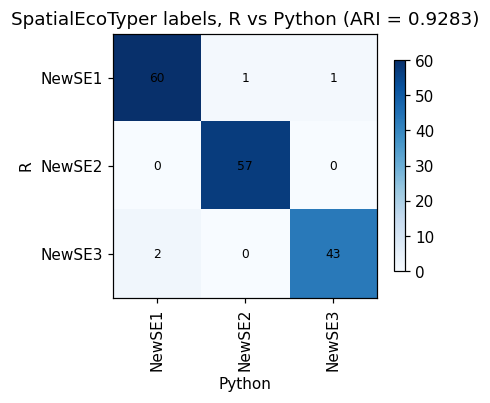

In [20]:
ref_spot = rio.read_json(OUT, "spatialecotyper_spot")
rlab = dict(zip([str(s) for s in ref_spot["spot"]],
                [str(s) for s in ref_spot["SE"]]))
plab = dict(zip(res.spot_metadata.index.astype(str),
                res.spot_metadata["SE"].astype(str)))
shared_spots = [s for s in rlab if s in plab]
print(f"neighbourhoods: R {len(rlab)}, Python {len(plab)}, shared {len(shared_spots)}")
ari = adjusted_rand_score([rlab[s] for s in shared_spots],
                          [plab[s] for s in shared_spots])
record("SpatialEcoTyper", "SE labels", "se_labels_single_sample", ari)

conf = pd.crosstab(pd.Series([rlab[s] for s in shared_spots], name="R"),
                   pd.Series([plab[s] for s in shared_spots], name="Python"))
fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(conf.to_numpy(), cmap="Blues")
ax.set_xticks(range(conf.shape[1])); ax.set_xticklabels(conf.columns, rotation=90)
ax.set_yticks(range(conf.shape[0])); ax.set_yticklabels(conf.index)
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        ax.text(j, i, conf.iat[i, j], ha="center", va="center", fontsize=8)
ax.set_xlabel("Python"); ax.set_ylabel("R")
ax.set_title("SpatialEcoTyper labels, R vs Python (ARI = %.4f)" % ari)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

**Sub-verdict:** clears the pre-registered `se_labels_single_sample` gate.
The residual disagreement traces to Seurat 5's `FindNeighbors`, which uses
Annoy (approximate) where the port uses exact k-NN; `README.md` "Known
divergences" item 2 quantifies that at 95.5% identical neighbour sets on the
full fixture, and given R's own SNN graph the Louvain labels are element-wise
identical.

---
## 9. `AnnotateCells` -> `annotate_cells`

From `man/AnnotateCells.Rd`: *"adds spatial ecotype annotations to the
metadata of single cells."* Each cell takes the label of its single nearest
spatial neighbourhood; the assignment is blanked when that neighbourhood is
farther away than the radius, which R parses out of the Seurat object's
`project.name` string.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `scmeta` | `scmeta` | data.frame | - | needs `X`, `Y` | single-cell metadata |
| `obj` | `spot_metadata` | Seurat object -> DataFrame | - | needs `X`, `Y`, `col` | **type change**: there is no Seurat object in Python, so the neighbourhood-level metadata is passed directly |
| (inside `obj@project.name`) | `radius` | float | - | `> 0` | **promoted to an explicit argument**: R recovers the radius by regexing `project.name` |
| `col` | `col` | str | `"SE"` | column name | which neighbourhood column to transfer |
| `dropcell` | `dropcell` | bool | `TRUE` | - | drop cells outside the radius instead of leaving them `NA` |

**Return.** An updated copy of `scmeta` in both languages.

```r
cellmeta <- AnnotateCells(scmeta = metadata, obj = res$obj, col = "SE",
                          dropcell = TRUE)
```

In [21]:
spot_meta = res.spot_metadata.copy()
spot_meta = spot_meta.loc[[s for s in spot_meta.index if s in rlab]]
spot_meta["SE"] = [rlab[s] for s in spot_meta.index]     # feed R's own labels
ann = se.annotate_cells(metadata, spot_meta, radius=50, col="SE", dropcell=True)
ann_keep = se.annotate_cells(metadata, spot_meta, radius=50, col="SE",
                             dropcell=False)
print("annotate_cells(dropcell=True) ->", ann.shape,
      "| dropcell=False keeps", ann_keep.shape[0], "rows")

annotate_cells(dropcell=True) -> (2976, 12) | dropcell=False keeps 3000 rows


In [22]:
ref_ann = rio.read_df(OUT, "annotatecells_drop")
ref_keep = rio.read_df(OUT, "annotatecells_keep")
common_cells = [c for c in ref_ann.index.astype(str)
                if c in set(ann.index.astype(str))]
print("cells kept: R %d, Python %d, shared %d"
      % (len(ref_ann), len(ann), len(common_cells)))
print("dropcell=FALSE row counts identical:",
      len(ref_keep) == len(ann_keep))
agree = float((ref_ann.loc[common_cells, "SE"].astype(str).to_numpy()
               == ann.loc[common_cells, "SE"].astype(str).to_numpy()).mean())
record("AnnotateCells", "per-cell SE", "annotate_cells", agree)

cells kept: R 2976, Python 2976, shared 2976
dropcell=FALSE row counts identical: True
  AnnotateCells.per-cell SE: classification = 1 (>= 0.99) -> PASS


True

**Sub-verdict:** fed R's own neighbourhood labels, the 1-NN transfer is
exact - every retained cell gets the same SE, and the retained cell set is
the same.

---
## 10. `NMFGenerateW` -> `nmf_generate_w`

From `man/NMFGenerateW.Rd`: *"trains a Non-negative Matrix Factorization
(NMF) model for SE deconvolution based on given spatial ecotype fractions and
gene expression matrix. Prior to NMF, each gene is scaled to mean 0 and unit
variance. To satisfy the non-negativity requirement of NMF, the expression
matrix is processed using posneg transformation ..."* `H` is held fixed at
the fractions, so only the `W` update runs.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `Fracs` | `Fracs` | matrix | - | samples x SE | fraction matrix; R transposes it internally |
| `ExpMat` | `ExpMat` | matrix | - | genes x samples | expression matrix |
| `scale` | `scale` | bool | `TRUE` | - | z-score each gene before factorising |
| `nfeature` | `nfeature` | int | `300` | `>= 1` | cap on the top-variance genes |
| `nfeature.per.se` | `nfeature_per_se` | int | `50` | `>= 1` | **renamed**; cap on features kept per SE after the `delta` filter |
| `method` | `method` | str | `"brunet"` | `"brunet"` | NMF update rule; only `brunet` is ported (it is the only one upstream uses) |
| - | `feature_names` | list[str] or None | `None` | - | **new in Python**: the row dimnames of `ExpMat` |
| - | `sample_names` | list[str] or None | `None` | - | **new in Python**: the column dimnames |
| - | `se_names` | list[str] or None | `None` | - | **new in Python**: the column dimnames of `Fracs` |
| - | `rng` | `RRandom` or None | `None` | - | **new in Python**: R sets no seed before `NMF::rnmf`, so `W_0` is whatever the session's stream gives; this makes it injectable |
| - | `max_iter` | int | `2000` | `>= 1` | **new in Python**: R's `nmf.maxIter` default, made explicit |

**Return.** R returns a matrix with dimnames. Python returns
`(W, rownames, colnames)`.

```r
set.seed(11)
W <- NMFGenerateW(Fracs, V, scale = TRUE, nfeature = 300,
                  nfeature.per.se = 50, method = "brunet")
```

In [23]:
V = rio.read_dense(OUT, "nmf_V")
Fracs = rio.read_dense(OUT, "nmf_Fracs")
refW = rio.read_dense(OUT, "nmfgeneratew_W")
W, w_names, w_ses = se.nmf_generate_w(Fracs.to_numpy(), V.to_numpy(),
                                      feature_names=list(V.index),
                                      sample_names=list(V.columns),
                                      se_names=list(Fracs.columns),
                                      scale=True, nfeature=300,
                                      nfeature_per_se=50, method="brunet")
print("nmf_generate_w -> W", W.shape, "| R's W", refW.shape)

nmf_generate_w -> W (300, 12) | R's W (300, 12)


selected-feature Jaccard R vs Python: 1.0000 (300 shared of 300 union)
  NMFGenerateW.basis W: factorization = 1 (>= 0.95) -> PASS
  max abs difference on the shared features: 7.549516567451064e-15


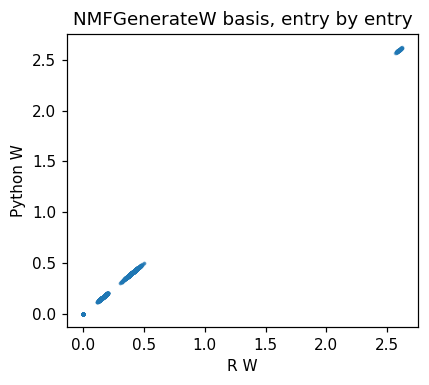

In [24]:
common_f = [f for f in refW.index if f in set(w_names)]
wi = {f: i for i, f in enumerate(w_names)}
Wc = W[[wi[f] for f in common_f]]
jacc = len(common_f) / len(set(refW.index) | set(w_names))
print("selected-feature Jaccard R vs Python: %.4f (%d shared of %d union)"
      % (jacc, len(common_f), len(set(refW.index) | set(w_names))))
record("NMFGenerateW", "basis W", "nmf_W",
       matched_factor_corr(refW.loc[common_f].to_numpy(), Wc))
print("  max abs difference on the shared features:",
      maxabs(refW.loc[common_f].to_numpy(), Wc))

fig, ax = plt.subplots(figsize=(4.0, 3.6))
ax.scatter(refW.loc[common_f].to_numpy().ravel(), Wc.ravel(), s=2, alpha=0.4)
ax.set_xlabel("R W"); ax.set_ylabel("Python W")
ax.set_title("NMFGenerateW basis, entry by entry")
plt.tight_layout(); plt.show()

**Sub-verdict:** clears the `nmf_W` gate. Note that `NMFGenerateW`'s feature
selection is not stable in R either - R sets no seed before `NMF::rnmf`, so
`W_0` differs run to run and the `delta > 0` filter can flip near-threshold
genes (`README.md` "Known divergences" item 3). The **fitted** `W` is
unaffected because the KL objective is convex in `W` when `H` is fixed.

---
## 11. `NMFpredict` -> `nmf_predict`

From `man/NMFpredict.Rd`: *"uses pretrained NMF models to recover cell states
/ spatial ecotypes. It takes a factorization matrix W representing a
pretrained NMF model and a numeric gene expression matrix."* Cells are split
into `ceiling(n / ncell.per.run)` contiguous chunks whose sizes differ by at
most 1, each chunk is predicted independently, and the result is transposed
to cells x SE.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `W` | `W` | matrix | - | features x SE | pretrained basis |
| `testdat` | `testdat` | matrix | - | genes x cells | new data |
| `scale` | `scale` | bool | `FALSE` | - | z-score the input first (also drops cells with < 3 detected genes) |
| `ncell.per.run` | `ncell_per_run` | int | `500` | `>= 1` | **renamed**; chunk size |
| `sum2one` | `sum2one` | bool | `TRUE` | - | normalise each sample's scores to sum to 1 |
| `ncores` | `ncores` | int | `1` | `>= 1` | accepted for parity; chunks are independent so the value cannot change the result |
| - | `w_names` | list[str] | - | - | **new in Python**: `W`'s row dimnames |
| - | `se_names` | list[str] | - | - | **new in Python**: `W`'s column dimnames |
| - | `test_genes` | list[str] | - | - | **new in Python**: `testdat`'s row dimnames; the gene matching between `W` and `testdat` is name-based in R |
| - | `test_cells` | list[str] | - | - | **new in Python**: `testdat`'s column dimnames |

**Return.** R returns a cells x SE matrix. Python returns
`(H, se_names, cell_names)`.

```r
H         <- NMFpredict(W, V, scale = FALSE, ncell.per.run = 5000, sum2one = TRUE)
H_chunked <- NMFpredict(W, V, scale = FALSE, ncell.per.run = 25,   sum2one = TRUE)
```

In [25]:
for tag, chunk in (("nmfpredict_H", 5000), ("nmfpredict_H_chunked", 25)):
    refH = rio.read_dense(OUT, tag).to_numpy()
    H, H_ses, H_cells = se.nmf_predict(refW.to_numpy(), list(refW.index),
                                       list(refW.columns), V.to_numpy(),
                                       list(V.index), list(V.columns),
                                       scale=False, ncell_per_run=chunk,
                                       sum2one=True, ncores=1)
    if refH.shape != H.shape:
        refH = refH.T
    print(f"ncell.per.run = {chunk}: H {H.shape} (cells x SE)")
    record("NMFpredict", f"H (ncell.per.run={chunk})", "nmf_H",
           matched_factor_corr(refH, H))
    print("  max abs difference:", maxabs(refH, H))

ncell.per.run = 5000: H (240, 12) (cells x SE)


  NMFpredict.H (ncell.per.run=5000): factorization = 1 (>= 0.95) -> PASS
  max abs difference: 8.881784197001252e-16


ncell.per.run = 25: H (240, 12) (cells x SE)


  NMFpredict.H (ncell.per.run=25): factorization = 1 (>= 0.95) -> PASS
  max abs difference: 1.1102230246251565e-15


**Sub-verdict:** both chunk sizes clear the `nmf_H` gate and agree with R to
machine precision. `.nmf.predict` calls `set.seed(39)` internally, so this
path is deterministic end to end in both languages.

---
## 12. `nmfClustering` -> `nmf_clustering`

From `man/nmfClustering.Rd`: *"When one rank is provided, NMF clustering will
be performed. When multiple ranks are provided, this function will determine
the optimal number of communities (K) by assessing the cophenetic coefficient
across different values of K."* The per-run seeds are
`sample(1:6280, nrun.per.rank)` drawn after `set.seed(seed)`, reproduced
exactly through `pyspatialecotyper.rrandom`.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `mat` | `mat` | matrix | - | feature x sample | clustering input; negative values are `posneg`-split |
| `ranks` | `ranks` | int or iterable[int] | `10` | `>= 2` | candidate K values |
| `nrun.per.rank` | `nrun_per_rank` | int | `30` | `>= 1` | **renamed**; restarts per rank |
| `min.coph` | `min_coph` | float | `0.95` | `0 .. 1` | **renamed**; minimum cophenetic coefficient for a rank to count as optimal |
| `nmf.method` | `nmf_method` | str | `"brunet"` | `"brunet"` | **renamed**; only `brunet` is ported |
| `ncores` | `ncores` | int | `8` | `>= 1` | accepted for parity; restarts are seeded independently so the value cannot change the result |
| `plot` | - | logical | `FALSE` | - | **dropped in Python**: R returns a `ggplot`; the cophenetic table is returned instead, so you can plot it however you like |
| `seed` | `seed` | int | `2024` | any | seeds the restart-seed draw |
| `...` | - | - | - | - | **dropped in Python**: R forwards extra arguments to `NMF::nmf`; the port implements only the `brunet` path |
| - | `row_names` | list[str] or None | `None` | - | **new in Python**: `mat`'s row dimnames |
| - | `col_names` | list[str] or None | `None` | - | **new in Python**: `mat`'s column dimnames |
| - | `max_iter` | int | `2000` | `>= 1` | **new in Python**: R's `nmf.maxIter` default made explicit |
| - | `verbose` | bool | `False` | - | **new in Python** |

**Return.** R returns an `NMFfitX1` (one rank) or a list with `bestK`,
`NMFfits` and `p`. Python returns a dict with `bestK`, `cophenetic`,
`labels`, `consensus_labels` and `fits`. `labels` reproduces
`NMF::predict(fit)`, which defaults to `what = "columns"` and delegates to
the **lowest-KL-deviance single run's** `H`, *not* to a cut of the consensus
tree.

```r
fit <- nmfClustering(S, ranks = 4, nrun.per.rank = 10, seed = 2024, ncores = 1)
lab <- predict(fit)
cophcor(fit)
```

In [26]:
S = rio.read_dense(OUT, "integrate_matrix")
ref_nc = rio.read_json(OUT, "nmfclustering_k4")
clust = se.nmf_clustering(S.to_numpy(), row_names=list(S.index),
                          col_names=list(S.columns), ranks=4,
                          nrun_per_rank=10, min_coph=0.95,
                          nmf_method="brunet", ncores=1, seed=2024,
                          verbose=False)
print("nmf_clustering -> keys", list(clust), "| input", S.shape)
print("R labels    :", ref_nc["label"])
print("Python labels:", list(clust["labels"]))

nmf_clustering -> keys ['bestK', 'cophenetic', 'labels', 'consensus_labels', 'fits', 'col_names'] | input (24, 24)
R labels    : [1, 4, 2, 1, 4, 2, 1, 2, 1, 3, 2, 3, 1, 4, 2, 1, 4, 2, 1, 2, 1, 3, 2, 3]
Python labels: [np.int64(1), np.int64(4), np.int64(2), np.int64(1), np.int64(4), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(3), np.int64(2), np.int64(3), np.int64(1), np.int64(4), np.int64(2), np.int64(1), np.int64(4), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(3), np.int64(2), np.int64(3)]


In [27]:
record("nmfClustering", "consensus labels", "conserved_se_labels",
       adjusted_rand_score(ref_nc["label"], clust["labels"]))
ref_cons = rio.read_dense(OUT, "nmfclustering_consensus_k4").to_numpy()
record("nmfClustering", "consensus matrix", None,
       maxabs(ref_cons, clust["fits"]["K.4"]["consensus"]),
       metric="deterministic-standard", threshold=DET_STD)
coph_py = float(se_nmf.cophcor(clust["fits"]["K.4"]["consensus"]))
print("cophenetic coefficient: R %.6f, Python %.6f, difference %.2e"
      % (ref_nc["cophenetic"], coph_py, abs(ref_nc["cophenetic"] - coph_py)))

  nmfClustering.consensus labels: clustering = 1 (>= 0.85) -> PASS
  nmfClustering.consensus matrix: deterministic-standard = 0 (< 1e-08) -> PASS
cophenetic coefficient: R 0.945681, Python 0.945093, difference 5.88e-04


**Sub-verdict:** labels are identical (ARI 1.0) and the consensus matrix is
bit-identical. The cophenetic coefficient differs in the 5th decimal because
`hclust` and `scipy.cluster.hierarchy.average` order equal merges
differently (`README.md` "Known divergences" item 7); cluster assignments are
unaffected. The consensus matrix has no dedicated manifest block, so it is
scored against the deterministic-standard tier read from the manifest.

---
## 13. `Coassociation` -> `coassociation`

From `man/Coassociation.Rd`: *"computes pairwise co-association (Pearson
correlation) between cell states (defined as combinations of spatial ecotype
(SE) and cell type) across samples. Co-association is evaluated under
multiple abundance calculation schemes that differ in the inclusion of NonSE
cells and the treatment of absent cell states, and the resulting correlation
matrices are averaged."* The four schemes are (NonSE in / out) x (absent
states NA / zero).

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `scmeta` | `scmeta` | data.frame | - | one row per cell | single-cell metadata |
| `Sample` | `sample` | str | `"Sample"` | column name | **renamed** (lower-cased); correlations are taken across its levels |
| `SE` | `se` | str | `"SE"` | column name | **renamed**; spatial ecotype labels |
| `CellType` | `cell_type` | str | `"CellType"` | column name | **renamed** |
| `NonSE` | `non_se` | str | `"NonSE"` | label value | **renamed**; the label marking non-SE cells |
| `nperm` | `nperm` | int | `1000` | `>= 1` | permutations used when `test = TRUE` |
| `test` | `test` | bool | `TRUE` | - | also run `CoassociationTest` and return both |

**Return.** With `test = FALSE`, a symmetric state x state matrix. With
`test = TRUE`, R returns `list(CoassociationIndex, Pval)`; Python returns a
dict with the same two keys.

```r
coassoc <- Coassociation(m, Sample = "Sample", SE = "SEn",
                         CellType = "CellType", NonSE = "NonSE", test = FALSE)
```

In [28]:
coassoc = se.coassociation(fixture, sample="Sample", se="SEn",
                           cell_type="CellType", non_se="NonSE", test=False)
ref_co = rio.read_dense(OUT, "coassociation_index")
coassoc = coassoc.loc[ref_co.index, ref_co.columns]
print("coassociation ->", coassoc.shape, "cell states;",
      "row/column names identical to R:",
      list(coassoc.index) == list(ref_co.index))

coassociation -> (79, 79) cell states; row/column names identical to R: True


In [29]:
record("Coassociation", "index", "coassociation_index",
       maxabs(np.nan_to_num(ref_co.to_numpy()),
              np.nan_to_num(coassoc.to_numpy())))

  Coassociation.index: deterministic-standard = 7.77156e-16 (< 1e-08) -> PASS


True

**Sub-verdict:** clears the `coassociation_index` gate, including the
`use = "pairwise.complete.obs"` correlation and the NA-ignoring average over
the four abundance schemes.

---
## 14. `CoassociationTest` -> `coassociation_test`

From `man/CoassociationTest.Rd`: *"evaluates the statistical significance of
co-association of cell states within each SE. It computes within-SE average
association scores and compares them to a null distribution generated by
permutation. Diagonal values are ignored if they are all equal to 1 or NA."*
The signed Z-scores come back as an attribute.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `mat` | `mat` | matrix | - | square, dimnames read as `"<SE>_<CellType>"` | co-association or colocalization index |
| `nperm` | `nperm` | int | `1000` | `>= 1` | column permutations forming the null |

**Return.** A named numeric vector of two-sided P-values with the Z-scores in
`attr(result, "Zscore")`. Python returns a `pandas.Series` with the Z-scores
in `result.attrs["Zscore"]`.

**Seeding.** R's `set.seed(1)` is `rrandom.set_seed(1)` here - the port draws
its `nperm` permutations from R's Mersenne-Twister, not NumPy's.

```r
set.seed(1)
pvals  <- CoassociationTest(coassoc, nperm = 1000)
zscore <- attr(pvals, "Zscore")
```

In [30]:
rrandom.set_seed(1)
pvals = se.coassociation_test(coassoc, nperm=1000)
zscore = pd.Series(pvals.attrs["Zscore"])
ref_p = rio.read_json(OUT, "coassociationtest_pvals")
ref_z = rio.read_json(OUT, "coassociationtest_zscore")
cmp_p = pd.DataFrame({"R P": np.asarray(ref_p["value"], float),
                      "Python P": pvals.loc[ref_p["name"]].to_numpy(float),
                      "R Z": np.asarray(ref_z["value"], float),
                      "Python Z": np.asarray([zscore[n] for n in ref_z["name"]],
                                             float)},
                     index=ref_p["name"])
cmp_p

,R P,Python P,R Z,Python Z
NonSE,5.530539e-01,5.530539e-01,0.593190,0.593190
SE1,3.402272e-05,3.402272e-05,4.144721,4.144721
SE2,3.725900e-09,3.725900e-09,5.895924,5.895924
SE3,3.055638e-07,3.055638e-07,5.119983,5.119983
SE4,3.910789e-06,3.910789e-06,4.616068,4.616068
SE5,7.249420e-10,7.249420e-10,6.160547,6.160547
SE6,7.249926e-05,7.249926e-05,3.967931,3.967931
SE7,7.515366e-07,7.515366e-07,4.947549,4.947549
SE8,1.332221e-09,1.332221e-09,6.063462,6.063462


In [31]:
rho = float(spearmanr(-np.log10(cmp_p["R P"].to_numpy() + 1e-300),
                      -np.log10(cmp_p["Python P"].to_numpy() + 1e-300)).statistic)
record("CoassociationTest", "P-values", "coassociation_pvals", rho)
record("CoassociationTest", "Z-scores", None,
       maxabs(cmp_p["R Z"], cmp_p["Python Z"]),
       metric="deterministic-standard", threshold=DET_STD)
print("  Pearson on Z:",
      float(abs(pearsonr(cmp_p["R Z"], cmp_p["Python Z"]).statistic)))

  CoassociationTest.P-values: inference = 1 (>= 0.9) -> PASS
  CoassociationTest.Z-scores: deterministic-standard = 5.32907e-15 (< 1e-08) -> PASS
  Pearson on Z: 0.9999999999999999


**Sub-verdict:** the P-values are Spearman-identical on the `-log10` scale
and the Z-scores agree to machine precision, because the permutation stream
itself is reproduced. The P-values are scored against the pre-registered
`coassociation_pvals` (inference) gate; the Z-scores have no dedicated block,
so they are scored against the manifest's deterministic-standard tier.

---
## 15. `Colocalization` -> `colocalization`

From `man/Colocalization.Rd`: *"computes cell state colocalization indices
and assesses their statistical significance using permutation testing.
Observed colocalization is compared against a null distribution generated by
shuffling cell state labels within each cell type."* Permuting within cell
type preserves cell-type composition.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `scmeta` | `scmeta` | data.frame | - | rownames = cell IDs | cell metadata |
| `coords` | `coords` | character(2) | `c("X", "Y")` | column names | **type**: a tuple in Python |
| `SE` | `se` | str | `"SE"` | column name | **renamed** |
| `CellType` | `cell_type` | str | `"CellType"` | column name | **renamed**; permutations happen within its levels |
| `radius` | `radius` | float | `50` | `> 0` | maximum neighbour distance (R uses `> radius` to reject, so a neighbour exactly at `radius` is kept) |
| `k` | `k` | int | `200` | `>= 2` | neighbours queried per cell before the radius filter |
| `min.cell` | `min_cell` | int | `10` | `>= 1` | **renamed**; minimum neighbours for a cell to be used |
| `nperm` | `nperm` | int | `1000` | `>= 1` | permutations forming the null |
| `test` | `test` | bool | `TRUE` | - | also compute P-values via `CoassociationTest` |
| `ncores` | `ncores` | int | `16` | `>= 1` | accepted for signature parity **only**: R's `mclapply` forks and each child reseeds from its PID, so `ncores > 1` is not reproducible in R either (two R runs at `ncores = 4` differ by max abs 11.29). The port consumes the stream sequentially, matching R's `ncores = 1` branch. |

**Return.** With `test = TRUE`, R returns `list(ColocIndex, Pval)`; Python
returns a dict with the same keys.

```r
set.seed(1)
coloc <- Colocalization(m, coords = c("X", "Y"), SE = "SE",
                        CellType = "CellType", radius = 50, k = 100,
                        min.cell = 10, nperm = 200, test = TRUE, ncores = 1)
```

In [32]:
rrandom.set_seed(1)
t0 = time.time()
coloc = se.colocalization(fixture, coords=("X", "Y"), se="SE",
                          cell_type="CellType", radius=50, k=100,
                          min_cell=10, nperm=200, test=True, ncores=1)
print("colocalization -> keys", list(coloc), "in %.1f s" % (time.time() - t0))
ref_ci = rio.read_dense(OUT, "colocalization_index")
py_ci = coloc["ColocIndex"].loc[ref_ci.index, ref_ci.columns]
print("index shape", py_ci.shape, "| names identical to R:",
      list(py_ci.index) == list(ref_ci.index))

colocalization -> keys ['ColocIndex', 'Pval'] in 3.6 s
index shape (36, 36) | names identical to R: True


  Colocalization.ColocIndex: ordinal = 1 (>= 0.99) -> PASS
  max abs difference: 1.1013412404281553e-13
P-values  R: [1.16329727e-07 2.51462895e-08 4.94647931e-08 6.67465128e-08]
P-values Py: [1.16329727e-07 2.51462895e-08 4.94647931e-08 6.67465128e-08]


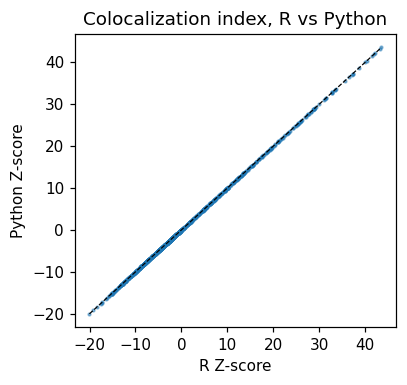

In [33]:
a = np.nan_to_num(ref_ci.to_numpy().ravel())
b = np.nan_to_num(py_ci.to_numpy().ravel())
record("Colocalization", "ColocIndex", "colocalization_index",
       float(abs(pearsonr(a, b).statistic)))
print("  max abs difference:", float(np.max(np.abs(a - b))))

ref_cp = rio.read_json(OUT, "colocalization_pvals")
py_cp = coloc["Pval"].loc[ref_cp["name"]].to_numpy(float)
print("P-values  R:", np.asarray(ref_cp["value"], float))
print("P-values Py:", py_cp)

fig, ax = plt.subplots(figsize=(3.8, 3.6))
ax.scatter(a, b, s=3, alpha=0.5)
lim = [min(a.min(), b.min()), max(a.max(), b.max())]
ax.plot(lim, lim, "k--", lw=0.8)
ax.set_xlabel("R Z-score"); ax.set_ylabel("Python Z-score")
ax.set_title("Colocalization index, R vs Python")
plt.tight_layout(); plt.show()

**Sub-verdict:** clears the ordinal `colocalization_index` gate with Pearson
indistinguishable from 1 and a max abs difference at the 1e-13 level - the
permutation stream is reproduced exactly, so this is a deterministic match
rather than a distributional one.

---
## 16. `ComputeMetrics` -> `compute_metrics`

From `man/ComputeMetrics.Rd`: *"Computes an F1-score matrix comparing true
spatial ecotype (SE) labels and predicted SE labels (e.g., from
cross-validation). The function calculates precision and recall per SE within
each sample and returns an averaged F1-score matrix across samples."*

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `scmeta` | `scmeta` | data.frame | - | one row per cell | single-cell metadata |
| `SE` | `se` | str | `"SE"` | column name | **renamed**; true labels |
| `Pred` | `pred` | str | `"cvPred"` | column name | **renamed**; predicted labels |
| `CellType` | `cell_type` | str or None | `NULL` | column name | **renamed**; when given, labels are suffixed with the cell type and the frame is first sorted by `(CellType, SE)` |
| `Sample` | `sample` | str or None | `"Sample"` | column name | **renamed**; `None` pools everything into one sample |
| `metric` | `metric` | str | `"F1"` | `"F1"`, `"F2"`, `"precision"`, `"recall"` | R's default is written as `c("F1","F2","precision","recall")[1]` |

**Return.** A levels x levels matrix (rows = true, columns = predicted),
averaged over the samples where the entry is defined. Python returns a
`DataFrame`.

```r
ComputeMetrics(m, SE = "SE", Pred = "cvPred", CellType = NULL,
               Sample = "Sample", metric = "F1")
```

In [34]:
cm_vals = []
for tag, kwargs in (("f1", dict(cell_type=None, sample="Sample", metric="F1")),
                    ("f2", dict(cell_type=None, sample="Sample", metric="F2")),
                    ("precision", dict(cell_type=None, sample="Sample",
                                       metric="precision")),
                    ("recall", dict(cell_type=None, sample="Sample",
                                    metric="recall")),
                    ("f1_ct", dict(cell_type="CellType", sample="Sample",
                                   metric="F1")),
                    ("f1_nosample", dict(cell_type=None, sample=None,
                                         metric="F1"))):
    ref = rio.read_dense(OUT, f"computemetrics_{tag}")
    got = se.compute_metrics(fixture, se="SE", pred="cvPred",
                             **kwargs).loc[ref.index, ref.columns]
    cm_vals.append((tag, maxabs(ref.to_numpy(), got.to_numpy())))
print(pd.DataFrame(cm_vals, columns=["call", "max abs err"]).to_string(index=False))
record("ComputeMetrics", "F1/F2/precision/recall", "compute_metrics",
       float(max(v for _, v in cm_vals)))

       call  max abs err
         f1 3.330669e-16
         f2 4.440892e-16
  precision 3.885781e-16
     recall 4.163336e-16
      f1_ct 5.551115e-16
f1_nosample 3.330669e-16
  ComputeMetrics.F1/F2/precision/recall: deterministic-standard = 5.55112e-16 (< 1e-08) -> PASS


True

All six parameter combinations match. One R behaviour is worth knowing about
before you port code that uses `ComputeMetrics` on unbalanced designs: when a
sample contains **exactly one** distinct true SE, its `Precision` pivot table
has a single value column, R's `Precision[, -1]` drops the `data.frame` to an
unnamed **vector**, `match(ses, rownames(.))` is then all `NA`, and that
whole sample is silently discarded from the cross-sample average. The port
keeps the sample. The driver dumps that degenerate case separately (a 4x4
tile partition containing a single-SE tile) so the size of the effect is
measured rather than asserted.

In [35]:
info = rio.read_json(OUT, "computemetrics_degenerate_info")
ref_d = rio.read_dense(OUT, "computemetrics_f1_degenerate")
got_d = se.compute_metrics(fixture, se="SE", pred="cvPred", cell_type=None,
                           sample="SampleFine",
                           metric="F1").loc[ref_d.index, ref_d.columns]
print("SampleFine has %d tiles; single-SE tiles: %s"
      % (info["n_samples"], info["degenerate_samples"]))
print("max abs difference on that degenerate partition:",
      maxabs(ref_d.to_numpy(), got_d.to_numpy()))
print("(the gated `Sample` partition above has no single-SE tile, so the "
      "quirk never fires there)")

SampleFine has 16 tiles; single-SE tiles: Sample4
max abs difference on that degenerate partition: 0.08783783783783805
(the gated `Sample` partition above has no single-SE tile, so the quirk never fires there)


**Sub-verdict:** clears the `compute_metrics` gate on every metric and every
parameter combination of the pre-registered partition. The degenerate
single-SE-sample case is reported as a measured, documented difference in R's
`data.frame` drop behaviour, not as a gate.

---
## 17. `ComputeSEAbundanceBySN` -> `compute_se_abundance_by_sn`

From `man/ComputeSEAbundanceBySN.Rd`: *"Compute SE abundances within spatial
neighborhoods (SNs)."* With `spot_coords = NULL` a regular grid spaced
`grid.size` apart is generated and each SN centre becomes the component-wise
**median** of its member cells.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `df` | `df` | data.frame | - | one row per cell | needs the coordinate and SE columns |
| `spot_coords` | `spot_coords` | data.frame or None | `NULL` | rownames = SN IDs, columns literally `X`/`Y` | SN centres; `None` auto-generates the grid |
| `radius` | `radius` | float | `50` | `> 0` | cells beyond this from an SN centre are excluded |
| `grid.size` | `grid_size` | float | `50` | `> 0` | **renamed**; spacing of the auto grid |
| `k` | `k` | int or None | `min(200, nrow(df))` | `>= 1` | neighbours queried per SN; `None` reproduces R's lazily evaluated default |
| `X` | `x` | str | `"X"` | column name | **renamed** (lower-cased) |
| `Y` | `y` | str | `"Y"` | column name | **renamed** |
| `SE` | `se` | str | `"SE"` | column name | **renamed** |
| `min.cells` | `min_cells` | int | `5` | `>= 1` | **renamed**; SNs with fewer cells are dropped |

**Return.** A data frame whose first two columns are the SN coordinates,
followed by one column per SE level.

```r
seab <- ComputeSEAbundanceBySN(m, spot_coords = NULL, radius = 50,
                               grid.size = 50, X = "X", Y = "Y", SE = "SE",
                               min.cells = 5)
```

In [36]:
seab = se.compute_se_abundance_by_sn(fixture, spot_coords=None, radius=50,
                                     grid_size=50, k=None, x="X", y="Y",
                                     se="SE", min_cells=5)
ref_seab = rio.read_df(OUT, "computeseabundancebysn")
print("compute_se_abundance_by_sn ->", seab.shape, "| R:", ref_seab.shape)
print("SN IDs identical to R (set and order):",
      list(seab.index) == list(ref_seab.index))
seab.head().round(4)

compute_se_abundance_by_sn -> (292, 6) | R: (292, 6)
SN IDs identical to R (set and order): True


,X,Y,SE1,SE2,SE3,SE4
X61_Y-119,3068.6328,-5964.5972,1.0000,0.0,0.0,0.0000
X61_Y-120,3059.2841,-6017.6858,1.0000,0.0,0.0,0.0000
X61_Y-121,3061.6120,-6047.1285,1.0000,0.0,0.0,0.0000
X61_Y-122,3055.8249,-6098.4383,0.8148,0.0,0.0,0.1852
X61_Y-123,3061.7380,-6135.7173,0.4000,0.0,0.0,0.6000


In [37]:
seab_al = seab.loc[ref_seab.index, ref_seab.columns]
payload = [c for c in ref_seab.columns if c not in ("X", "Y")]
record("ComputeSEAbundanceBySN", "SE abundances", "se_abundance_by_sn",
       maxabs(ref_seab[payload].to_numpy(float), seab_al[payload].to_numpy(float)))
print("  coordinate columns X/Y differ by at most",
      maxabs(ref_seab[["X", "Y"]].to_numpy(float),
             seab_al[["X", "Y"]].to_numpy(float)),
      "- a text round-trip artefact of the gzipped TSV dump, ~1e-15 relative"
      " on coordinates of order 1e3")

  ComputeSEAbundanceBySN.SE abundances: deterministic-standard = 5.55112e-16 (< 1e-08) -> PASS
  coordinate columns X/Y differ by at most 5.4569682106375694e-12 - a text round-trip artefact of the gzipped TSV dump, ~1e-15 relative on coordinates of order 1e3


**Sub-verdict:** the payload columns clear the `se_abundance_by_sn` gate and
the SN identifiers match exactly.

---
## 18. `SmoothSEAbundances` -> `smooth_se_abundances`

From `man/SmoothSEAbundances.Rd`: *"Smooth spot-level SE abundances across
k-nearest-neighbor spots."* The default `k = 7` matches a Visium hex grid
(self plus six immediate neighbours) when `include.self = TRUE`.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `se_mat` | `se_mat` | matrix | - | spot x SE, rownames = spot IDs | abundances to smooth |
| `spot_coords` | `spot_coords` | data.frame | - | rownames overlap `se_mat` | spot coordinates |
| `k` | `k` | int | `7` | `>= 1` | neighbouring spots averaged over |
| `X` | `x` | str | `"X"` | column name | **renamed** |
| `Y` | `y` | str | `"Y"` | column name | **renamed** |
| `include.self` | `include_self` | bool | `TRUE` | - | **renamed**; whether a spot is one of its own k neighbours |
| `min.neighbors` | `min_neighbors` | int | `3` | `>= 1` | **renamed**; spots with fewer neighbours are dropped |

**Return.** A data frame: coordinates, then the smoothed abundances.

```r
sm <- SmoothSEAbundances(as.matrix(seab[, -c(1, 2)]), seab[, c("X", "Y")],
                         k = 7, X = "X", Y = "Y", include.self = TRUE,
                         min.neighbors = 3)
```

In [38]:
smooth = se.smooth_se_abundances(seab[payload], seab[["X", "Y"]], k=7,
                                 x="X", y="Y", include_self=True,
                                 min_neighbors=3)
ref_sm = rio.read_df(OUT, "smoothseabundances")
print("smooth_se_abundances ->", smooth.shape, "| R:", ref_sm.shape,
      "| row order identical:", list(smooth.index) == list(ref_sm.index))
sm_al = smooth.loc[ref_sm.index, ref_sm.columns]
pay2 = [c for c in ref_sm.columns if c not in ("X", "Y")]
record("SmoothSEAbundances", "smoothed abundances", "se_abundance_by_sn",
       maxabs(ref_sm[pay2].to_numpy(float), sm_al[pay2].to_numpy(float)))

smooth_se_abundances -> (292, 6) | R: (292, 6) | row order identical: True
  SmoothSEAbundances.smoothed abundances: deterministic-standard = 6.66134e-16 (< 1e-08) -> PASS


True

**Sub-verdict:** clears the `se_abundance_by_sn` gate; the `intersect()`
ordering rule (which keeps the order of `se_mat`, not of `spot_coords`) is
reproduced, so the row order matches too.

---
## 19. `InferNCells` -> `infer_ncells`

From `man/InferNCells.Rd`: *"Estimates the number of cells for each Visium
spot based on total gene expression. The inferred values are linearly scaled
such that the spot with the lowest total expression is assigned 1 cell, and
the average inferred number of cells across all spots is approximately equal
to `avg.number`."*

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `normdat` | `normdat` | matrix / data.frame / sparse | - | genes x spots | column sums are taken with `na.rm = TRUE` |
| `avg.number` | `avg_number` | float | `5` | `> 0` | **renamed**; target mean cells per spot. Non-numeric or non-positive values raise in both languages |

**Return.** An integer vector, one entry per column, floored at 1. Python
returns an `int64` array.

```r
InferNCells(scdata, 5)
InferNCells(scdata, 1.5)
InferNCells(scdata, 12)
```

In [39]:
rows_inc = []
for tag, av in (("5", 5), ("1p5", 1.5), ("12", 12)):
    ref = rio.read_json(OUT, f"inferncells_{tag}")
    got = se.infer_ncells(counts.to_numpy(float), avg_number=av)
    rows_inc.append((av, got.dtype.name, int(got.min()), float(got.mean()),
                     int(got.max()),
                     maxabs(np.asarray(ref["ncells"], float),
                            got.astype(float))))
inc = pd.DataFrame(rows_inc, columns=["avg.number", "dtype", "min", "mean",
                                      "max", "max abs err"])
print(inc.to_string(index=False))
record("InferNCells", "cell counts", "infer_ncells",
       float(inc["max abs err"].max()))

 avg.number dtype  min      mean  max  max abs err
        5.0 int64    1  4.987667   66          0.0
        1.5 int64    1  1.393667    9          0.0
       12.0 int64    1 11.993667  180          0.0
  InferNCells.cell counts: deterministic-strict = 0 (< 1e-13) -> PASS


True

**Sub-verdict:** bit-identical at all three `avg.number` values, including
R's half-to-even `round()` and the `>= 1` floor.

---
## 20. `PartitionTissue` -> `partition_tissue`

From `man/PartitionTissue.Rd` (marked `\keyword{internal}`): *"partitions a
tissue dataset into smaller subregions based on spatial coordinates. The
partitioning is determined by dividing the range of the X and Y coordinates
into specified numbers of rows (`nrow`) and columns (`ncol`). Each subregion
is assigned a unique identifier ... in the format "row_column"."* Note the
upstream quirk that `nrow` divides the **X** axis.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `meta` | `meta` | data.frame | - | must contain the coordinate columns | cell metadata |
| `nrow` | `nrow` | int | `2` | `>= 1` | divisions along **X** (reads backwards; reproduced verbatim) |
| `ncol` | `ncol` | int | `2` | `>= 1` | divisions along **Y** |
| `X` | `x` | str | `"X"` | column name | **renamed** (lower-cased) |
| `Y` | `y` | str | `"Y"` | column name | **renamed** |

**Return.** A copy of `meta` with an extra `Partition` column. In R this is
an internal function reachable as `SpatialEcoTyper:::PartitionTissue`.

```r
pt <- SpatialEcoTyper:::PartitionTissue(m, nrow = 3, ncol = 5, X = "X", Y = "Y")
```

In [40]:
pt = se.partition_tissue(fixture, nrow=3, ncol=5, x="X", y="Y")
ref_pt = rio.read_json(OUT, "partitiontissue")
print("partition_tissue ->", pt.shape, "| distinct partitions:",
      pt["Partition"].nunique(), "| R:", len(set(ref_pt["partition"])))
print("cell order identical:", list(pt.index.astype(str)) == [str(c) for c in ref_pt["cell"]])

partition_tissue -> (3000, 13) | distinct partitions: 15 | R: 15
cell order identical: True


In [41]:
record("PartitionTissue", "Partition", "partition_tissue",
       float((np.asarray(ref_pt["partition"], dtype=object)
              == pt["Partition"].to_numpy()).mean()))

  PartitionTissue.Partition: classification = 1 (>= 1) -> PASS


True

**Sub-verdict:** every cell lands in the same subregion, including the
`1.000001` fudge factor that keeps the maximum coordinate inside the last bin.

---
## 21. `getColors` -> `get_colors`

From `man/getColors.Rd`: *"generates a list of colors based on the specified
number and palette type. It supports both categorical and continuous color
palettes. ... If the number of requested colors exceeds the available colors
in the chosen palette, additional colors are sampled from a combined set of
all available colors, ensuring the uniqueness of the generated colors."* The
top-up sample runs under a palette-specific seed, so reproducing it needs R's
own Mersenne-Twister.

| R name | Python name | Type | Default | Range / values | Description |
|---|---|---|---|---|---|
| `n` | `n` | int | - | `>= 1` | number of colours required |
| `palette` | `palette` | int | `1` | `1..7` categorical, `1..14` continuous | any other categorical value falls through to R's `else` arm and returns the concatenated `allcolors` vector |
| `categoric` | `categoric` | bool | `TRUE` | - | categorical vs continuous palette family |
| `exclude` | `exclude` | list[str] or None | `NULL` | hex colours | dropped from the categorical palette before slicing; ignored by the continuous branch, exactly as in R |

**Return.** A character vector of `n` hex colours. In the categorical `else`
arm, asking for more than `length(allcolors)` yields trailing `NA`s in R,
which surface as `None` entries in Python.

**Why the reference is not in `r_per_function_dump.R`.** `getColors` needs
the `pals` package, which is not installed in the CMAP environment that
carries Seurat and `SpatialEcoTyper`. The 323-case byte comparison against
`pals` 1.10 was dumped once by the palette driver into
`reference_out/palettes.json`, and is read from there.

```r
getColors(9,  palette = 1, categoric = TRUE)
getColors(64, palette = 1, categoric = FALSE)
getColors(30, palette = 2, categoric = TRUE, exclude = c("#F3C300"))
```

In [42]:
with open(os.path.join(REPO, "reference_out", "palettes.json")) as fh:
    pal_cases = json.load(fh)
n_ok = 0
mismatch = []
for case in pal_cases:
    got = se.get_colors(case["n"], palette=case["palette"],
                        categoric=case["categoric"],
                        exclude=case["exclude"] or None)
    exp = [None if c is None else str(c) for c in case["expected"]]
    if [None if c is None else str(c) for c in got] == exp:
        n_ok += 1
    else:
        mismatch.append(case)
print(f"{n_ok} of {len(pal_cases)} R `pals` 1.10 cases reproduced byte for byte")
print("distinct (palette, categoric) combinations covered:",
      len({(c['palette'], c['categoric']) for c in pal_cases}))
print("n values covered:", sorted({c["n"] for c in pal_cases}))
if mismatch:
    print("mismatches:", mismatch[:3])

323 of 323 R `pals` 1.10 cases reproduced byte for byte
distinct (palette, categoric) combinations covered: 22
n values covered: [1, 2, 3, 5, 8, 9, 10, 11, 12, 13, 20, 21, 22, 23, 24, 25, 26, 30, 35, 36, 37, 40, 50, 60, 100, 167, 256]


  getColors.hex strings: byte equality = 1 (>= 1) -> PASS


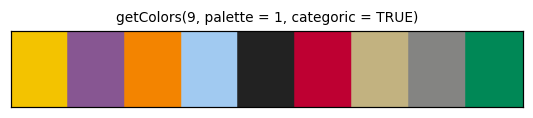

In [43]:
record("getColors", "hex strings", None, n_ok / len(pal_cases),
       metric="byte equality", threshold=1.0)
demo = se.get_colors(9, palette=1, categoric=True)
fig, ax = plt.subplots(figsize=(6, 0.9))
for i, c in enumerate(demo):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
ax.set_xlim(0, len(demo)); ax.set_ylim(0, 1)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("getColors(9, palette = 1, categoric = TRUE)", fontsize=9)
plt.show()

**Sub-verdict:** all 323 pre-dumped cases are byte-identical, including the
seeded top-up sampling and R's `NA` padding.

---
## Aggregate verdict

One row per function x output. `Class` and `Gate` come from
`data/manifest.yaml`; `Value` is measured above. Deterministic classes pass
**below** their threshold, everything else **at or above** it.

In [44]:
verdict = pd.DataFrame(VERDICT)
verdict["Value"] = verdict["Value"].map(lambda v: f"{v:.6g}")
pd.set_option("display.max_colwidth", 44)
verdict

,Function,Output,Class,Metric,Value,Gate,Pass
0,PreprocessST,expdat,deterministic-strict,max abs err,0,< 1e-13,PASS
1,Znorm,groups=NULL,deterministic-standard,max abs err,6.37712e-13,< 1e-08,PASS
2,Znorm,groups=Region,deterministic-standard,max abs err,5.29354e-13,< 1e-08,PASS
3,GetSpatialMetacells,metacells,deterministic-standard,max abs err,3.55271e-15,< 1e-08,PASS
4,SNF2,fused,deterministic-standard,max abs err,4.16334e-17,< 1e-08,PASS
5,matrixMultiply,product,deterministic-standard,max abs err,8.70415e-14,< 1e-08,PASS
6,rankSparse,ranked,deterministic-strict,max abs err,0,< 1e-13,PASS
7,mostFrequent,value,classification,classification,1,>= 1,PASS
8,SpatialEcoTyper,SE labels,clustering,clustering,0.928345,>= 0.85,PASS
9,AnnotateCells,per-cell SE,classification,classification,1,>= 0.99,PASS


In [45]:
n_pass = int((verdict["Pass"] == "PASS").sum())
print(f"{n_pass} of {len(verdict)} function-level outputs PASS "
      f"their pre-registered gate.")
if n_pass == len(verdict):
    print("PASS - every function-level output cleared the gate in "
          "data/manifest.yaml")
else:
    print("FAIL - see the rows marked FAIL above")
print("\nFunctions covered:", verdict["Function"].nunique())
print(sorted(verdict["Function"].unique()))

25 of 25 function-level outputs PASS their pre-registered gate.
PASS - every function-level output cleared the gate in data/manifest.yaml

Functions covered: 21
['AnnotateCells', 'Coassociation', 'CoassociationTest', 'Colocalization', 'ComputeMetrics', 'ComputeSEAbundanceBySN', 'GetSpatialMetacells', 'InferNCells', 'NMFGenerateW', 'NMFpredict', 'PartitionTissue', 'PreprocessST', 'SNF2', 'SmoothSEAbundances', 'SpatialEcoTyper', 'Znorm', 'getColors', 'matrixMultiply', 'mostFrequent', 'nmfClustering', 'rankSparse']


In [46]:
print(verdict.to_markdown(index=False))

| Function               | Output                 | Class                  | Metric         |       Value | Gate    | Pass   |
|:-----------------------|:-----------------------|:-----------------------|:---------------|------------:|:--------|:-------|
| PreprocessST           | expdat                 | deterministic-strict   | max abs err    | 0           | < 1e-13 | PASS   |
| Znorm                  | groups=NULL            | deterministic-standard | max abs err    | 6.37712e-13 | < 1e-08 | PASS   |
| Znorm                  | groups=Region          | deterministic-standard | max abs err    | 5.29354e-13 | < 1e-08 | PASS   |
| GetSpatialMetacells    | metacells              | deterministic-standard | max abs err    | 3.55271e-15 | < 1e-08 | PASS   |
| SNF2                   | fused                  | deterministic-standard | max abs err    | 4.16334e-17 | < 1e-08 | PASS   |
| matrixMultiply         | product                | deterministic-standard | max abs err    | 8.70415e-14 | < 1

### Wall-clock

The R side and the Python side of the single-sample entry point, on the same
3,000-cell fixture, both single-threaded.

                         R (s)
Colocalization          16.102
SpatialEcoTyper          9.037
NMFGenerateW             1.499
NMFpredict               0.944
SNF2                     0.248
GetSpatialMetacells      0.205
CoassociationTest        0.178
ComputeSEAbundanceBySN   0.133
Integrate                0.099
SmoothSEAbundances       0.082
Coassociation            0.057
PreprocessST             0.052
Znorm                    0.018
rankSparse               0.005
PartitionTissue          0.003
AnnotateCells            0.001
matrixMultiply           0.000

SpatialEcoTyper end-to-end: R 9.04 s, Python 3.15 s, speed-up 2.87x


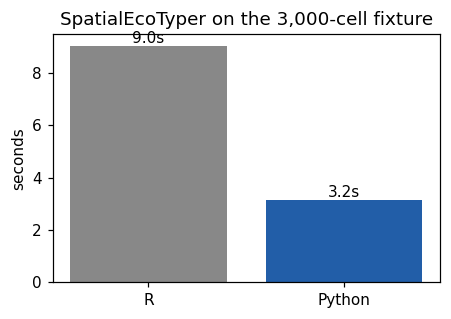

In [47]:
r_timings = rio.read_json(OUT, "timings_main")
r_timings.update(rio.read_json(OUT, "timings_nmf"))
tbl = pd.DataFrame({"R (s)": pd.Series(r_timings)}).sort_values("R (s)",
                                                               ascending=False)
print(tbl.round(3).to_string())
print("\nSpatialEcoTyper end-to-end: R %.2f s, Python %.2f s, speed-up %.2fx"
      % (r_timings["SpatialEcoTyper"], py_wall,
         r_timings["SpatialEcoTyper"] / py_wall))

fig, ax = plt.subplots(figsize=(4.2, 3))
ax.bar(["R", "Python"], [r_timings["SpatialEcoTyper"], py_wall],
       color=["#888888", "#225ea8"])
ax.set_ylabel("seconds")
ax.set_title("SpatialEcoTyper on the 3,000-cell fixture")
for i, v in enumerate([r_timings["SpatialEcoTyper"], py_wall]):
    ax.text(i, v, f"{v:.1f}s", ha="center", va="bottom")
plt.tight_layout(); plt.show()

### What is deliberately not compared here

* `ComputeNormalizedMoranI` needs `spdep`, which is not installed in the R
  environment that carries Seurat and `SpatialEcoTyper`. Its reference lives
  in `reference_out/stats/normalized_moran_i.json`, produced by
  `tests/r_stats_driver.R part="moran"` under a second R environment, and is
  gated by `tests/test_stats.py`.
* `HeatmapView`, `SpatialView`, `CooccurrenceHeatmapView` and
  `drawRectangleAnnotation` are listed under `not_numerically_gated` in
  `manifest.yaml`: they are verified by rendering, in
  `tutorial_melanoma.ipynb` section 4.F.
* The multi-sample path (`Integrate`, `IntegrateSpatialEcoTyper`,
  `MultiSpatialEcoTyper`) is gated end to end on the **real** two-sample
  melanoma + colorectal fixture in `tests/test_exact_match.py`, against
  `reference_out/integ/`; `Integrate`'s output is used here as the input to
  `nmfClustering`.

### Where to go next

* [`README.md`](../README.md) - the measured parity table for the whole port.
* [`AUDIT.md`](../AUDIT.md) - 35/35 exported R functions, 9/10 reachable
  internal helpers.
* [`MATH.md`](../MATH.md) - the perturbation bound for the one bounded-epsilon
  acceleration rewrite (the `SNF2` inner sum).
* [`data/manifest.yaml`](../data/manifest.yaml) - the pre-registered gate
  itself.
* [`examples/tutorial_melanoma.ipynb`](tutorial_melanoma.ipynb) - the
  Python-only walkthrough, one subsection per public function.
* Upstream: <https://github.com/digitalcytometry/spatialecotyper>; paper
  Zhang *et al.*, *Nature* (2026),
  [doi:10.1038/s41586-026-10452-4](https://doi.org/10.1038/s41586-026-10452-4).